# 03 — Modélisation
Comparaison de 3 modèles supervisés avec cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [2]:
df = pd.read_parquet('../data/decp_features.parquet')
print(df.shape)
df.head(3)

(8756, 26)


,id,objet,acheteur_id,montant,dureeMois,offresRecues,procedure,codeCPV,nb_titulaires,dateNotification,...,procedure_code,montant_par_mois,z_montant_cpv,taux_sans_conc_acheteur,nb_marches_acheteur,montant_moyen_acheteur,ratio_montant_acheteur,pca_1,pca_2,label
0,2022-884095-01,Transports collectifs pour la Ville d'Orvault:...,21440114300018,46000.0,12.0,1,Procédure adaptée,60,1,2022-07-29,...,0,3538.461538,-0.193438,0.06,50.0,276864.100000,0.166146,-0.366993,0.111994,1
1,2024-0202403100,"Travaux d'éclairage public, de signalisation l...",21680066400015,253530.0,8.0,2,Procédure adaptée,45,1,2024-07-11,...,0,28170.000000,-0.064566,0.00,36.0,661898.500000,0.383034,0.242508,0.030773,0
2,24-131-00,"LE MOLAY LITTRY - 53, 55, 57, 59, 61 et 63 rou...",78070570300012,113278.0,2.0,1,Procédure adaptée,45,1,2024-08-29,...,0,37759.333333,-0.082514,0.00,104.0,327778.692308,0.345592,-0.033810,0.157923,1


In [3]:
# On exclut les features binaires qui servent à construire le label
# pour éviter que le modèle triche
FEATURES = [
    'montant_log', 'dureeMois', 'offresRecues', 'nb_titulaires',
    'procedure_code', 'mois_notification',
    'montant_par_mois', 'z_montant_cpv',
    'taux_sans_conc_acheteur', 'nb_marches_acheteur', 'ratio_montant_acheteur',
    'pca_1', 'pca_2',
]

X = df[FEATURES].fillna(0)
y = df['label']

print(f'Suspects : {y.sum()} / {len(y)}')

Suspects : 2575 / 8756


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train : {X_train.shape[0]} — Test : {X_test.shape[0]}')

Train : 7004 — Test : 1752


## Les 3 modèles

In [5]:
modele_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

In [6]:
modele_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [7]:
modele_3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
])

## Cross-validation (5 folds)

In [8]:
scoring = ['f1', 'precision', 'recall', 'roc_auc']

cv_1 = cross_validate(modele_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_validate(modele_2, X_train, y_train, cv=5, scoring=scoring)
cv_3 = cross_validate(modele_3, X_train, y_train, cv=5, scoring=scoring)

print('Cross-validation terminée')

Cross-validation terminée


In [9]:
resultats = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest', 'XGBoost'],
    'F1': [cv_1['test_f1'].mean(), cv_2['test_f1'].mean(), cv_3['test_f1'].mean()],
    'Precision': [cv_1['test_precision'].mean(), cv_2['test_precision'].mean(), cv_3['test_precision'].mean()],
    'Recall': [cv_1['test_recall'].mean(), cv_2['test_recall'].mean(), cv_3['test_recall'].mean()],
    'AUC-ROC': [cv_1['test_roc_auc'].mean(), cv_2['test_roc_auc'].mean(), cv_3['test_roc_auc'].mean()],
}).round(3)

resultats

,Modèle,F1,Precision,Recall,AUC-ROC
0,Régression Logistique,0.881,0.896,0.866,0.931
1,Random Forest,0.998,0.999,0.997,1.000
2,XGBoost,1.000,1.000,1.000,1.000


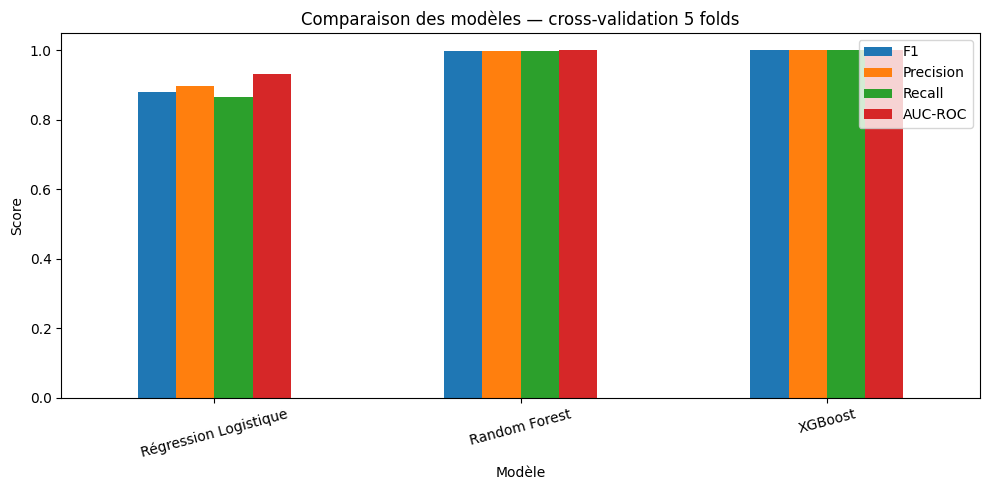

In [10]:
resultats.set_index('Modèle').plot(kind='bar', figsize=(10, 5))
plt.title('Comparaison des modèles — cross-validation 5 folds')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../plots/comparaison_modeles.png', dpi=150)
plt.show()

## Évaluation sur le test set

In [11]:
modele_3.fit(X_train, y_train)
y_pred = modele_3.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Suspect']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1226
     Suspect       1.00      1.00      1.00       526

    accuracy                           1.00      1752
   macro avg       1.00      1.00      1.00      1752
weighted avg       1.00      1.00      1.00      1752



In [12]:
joblib.dump(modele_3, '../models/xgboost.joblib')
print('Modèle sauvegardé : models/xgboost.joblib')

Modèle sauvegardé : models/xgboost.joblib
